# CNN from Scratch — CIFAR-10 Image Classification

Experiment with filters, kernel size and pooling; evaluate with accuracy and confusion matrix.

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

print('TensorFlow:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

I0000 00:00:1787636203.924642    5099 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow: 2.21.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0
y_train = y_train.flatten()
y_test = y_test.flatten()
print('Training:', x_train.shape)
print('Testing :', x_test.shape)

Training: (50000, 32, 32, 3)
Testing : (10000, 32, 32, 3)


In [3]:
class_names = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

In [4]:
def build_cnn(filters=32, kernel_size=(3,3), pooling='max'):
    pool = layers.MaxPooling2D((2,2)) if pooling == 'max' else layers.AveragePooling2D((2,2))
    model = models.Sequential([
        layers.Input(shape=(32,32,3)),
        layers.Conv2D(filters, kernel_size, activation='relu'),
        layers.Conv2D(filters, kernel_size, activation='relu'),
        pool,
        layers.Conv2D(filters*2, kernel_size, activation='relu'),
        layers.MaxPooling2D((2,2)),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

## Baseline CNN

In [11]:
model = build_cnn(32, (3,3), 'max')
model.summary()
history = model.fit(x_train, y_train, epochs=5, batch_size=64, validation_split=0.1, verbose=1)
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)
print('Test Accuracy:', round(test_accuracy*100,2), '%')

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_24 (Conv2D)              │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 12, 12, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 324,970 (1.24 MB)

 Trainable params: 324,970 (1.24 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5


I0000 00:00:1787637343.836097    5496 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_114633__.31


700/704 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4642 - loss: 1.4808

I0000 00:00:1787637350.871927    5494 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_114633__.31


704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.4647 - loss: 1.4797 - val_accuracy: 0.5900 - val_loss: 1.1648
Epoch 2/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.6318 - loss: 1.0494 - val_accuracy: 0.6474 - val_loss: 0.9919
Epoch 3/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.6929 - loss: 0.8795 - val_accuracy: 0.6848 - val_loss: 0.9163
Epoch 4/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7305 - loss: 0.7707 - val_accuracy: 0.7112 - val_loss: 0.8150
Epoch 5/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7602 - loss: 0.6836 - val_accuracy: 0.7208 - val_loss: 0.8125
Test Accuracy: 70.92 %


## Experiment 1 — Filters

In [6]:
filter_results = {}
for filters in [16,32,64]:
    print('Training with', filters, 'filters')
    m = build_cnn(filters, (3,3), 'max')
    m.fit(x_train,y_train,epochs=3,batch_size=64,validation_split=0.1,verbose=0)
    _,acc=m.evaluate(x_test,y_test,verbose=0)
    filter_results[filters]=acc
for k,v in filter_results.items(): print(k,'filters:',round(v*100,2),'%')

Training with 16 filters


W0000 00:00:1787636257.335051    5099 cpu_allocator_impl.cc:82] Allocation of 552960000 exceeds 10% of free system memory.
W0000 00:00:1787636257.936528    5099 cpu_allocator_impl.cc:82] Allocation of 552960000 exceeds 10% of free system memory.
I0000 00:00:1787636259.292285    5493 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_21214__.31
I0000 00:00:1787636267.079679    5495 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_21214__.31


Training with 32 filters


W0000 00:00:1787636282.964947    5099 cpu_allocator_impl.cc:82] Allocation of 552960000 exceeds 10% of free system memory.
I0000 00:00:1787636284.746673    5496 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_34212__.31
I0000 00:00:1787636291.193315    5496 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_34212__.31


Training with 64 filters


I0000 00:00:1787636309.323422    5496 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_47218__.31
I0000 00:00:1787636322.502522    5494 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_47218__.31


16 filters: 64.43 %
32 filters: 67.24 %
64 filters: 69.24 %


## Experiment 2 — Kernel Size

In [7]:
kernel_results = {}
for kernel in [(3,3),(5,5)]:
    print('Training with kernel', kernel)
    m=build_cnn(32,kernel,'max')
    m.fit(x_train,y_train,epochs=3,batch_size=64,validation_split=0.1,verbose=0)
    _,acc=m.evaluate(x_test,y_test,verbose=0)
    kernel_results[kernel]=acc
for k,v in kernel_results.items(): print(k,':',round(v*100,2),'%')

Training with kernel (3, 3)


I0000 00:00:1787636351.910058    5494 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_60216__.31
I0000 00:00:1787636358.755667    5496 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_60216__.31


Training with kernel (5, 5)


I0000 00:00:1787636377.329461    5493 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_73222__.31
I0000 00:00:1787636387.355418    5493 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_73222__.31


(3, 3) : 69.13 %
(5, 5) : 59.33 %


## Experiment 3 — Pooling

In [8]:
pooling_results = {}
for pooling in ['max','average']:
    print('Training with', pooling, 'pooling')
    m=build_cnn(32,(3,3),pooling)
    m.fit(x_train,y_train,epochs=3,batch_size=64,validation_split=0.1,verbose=0)
    _,acc=m.evaluate(x_test,y_test,verbose=0)
    pooling_results[pooling]=acc
for k,v in pooling_results.items(): print(k,'pooling:',round(v*100,2),'%')

Training with max pooling


I0000 00:00:1787636409.452213    5495 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_86220__.31
I0000 00:00:1787636416.474791    5493 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_86220__.31


Training with average pooling


I0000 00:00:1787636434.095997    5495 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_99220__.27
I0000 00:00:1787636439.998289    5493 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_99220__.27


max pooling: 67.51 %
average pooling: 65.79 %


## Confusion Matrix

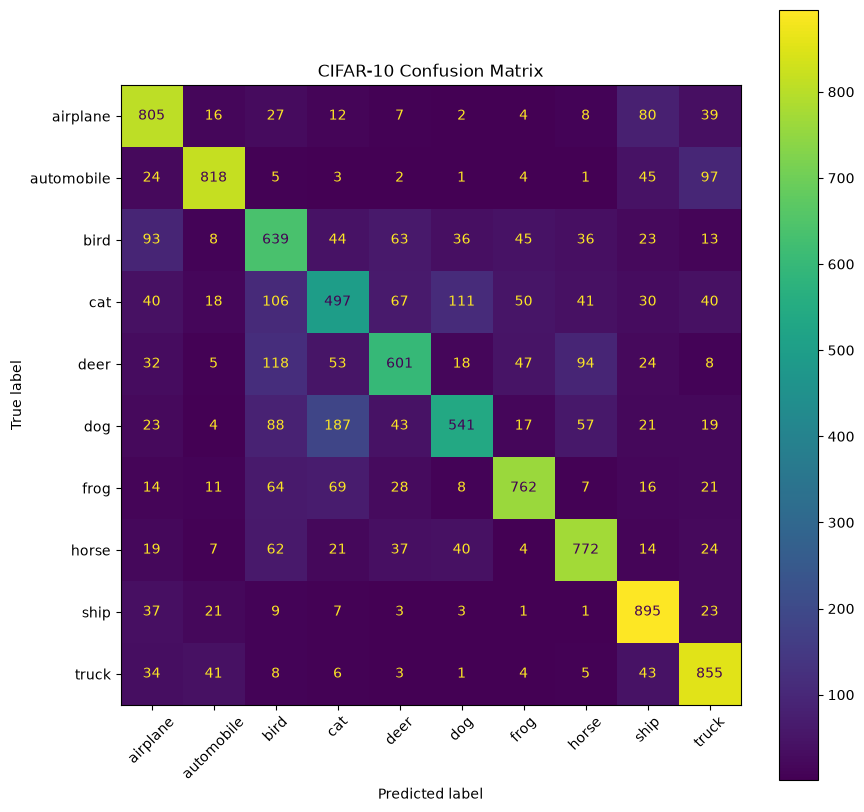

In [9]:
y_pred=np.argmax(model.predict(x_test,verbose=0),axis=1)
cm=confusion_matrix(y_test,y_pred)
disp=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=class_names)
fig,ax=plt.subplots(figsize=(10,10))
disp.plot(ax=ax,xticks_rotation=45)
plt.title('CIFAR-10 Confusion Matrix')
plt.show()

## Accuracy Curve

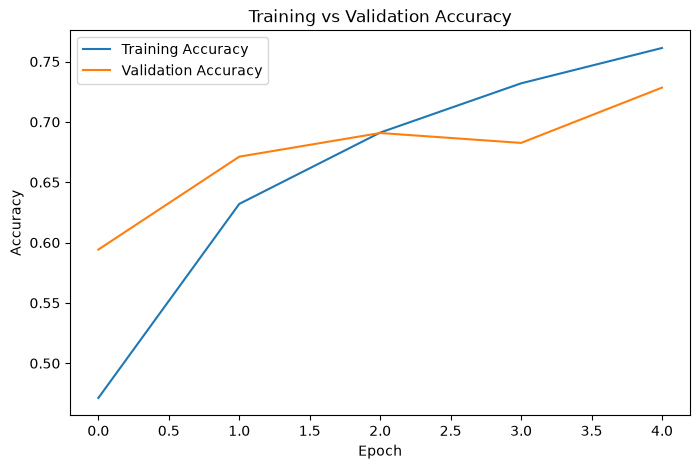

In [10]:
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'],label='Training Accuracy')
plt.plot(history.history['val_accuracy'],label='Validation Accuracy')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.title('Training vs Validation Accuracy'); plt.legend(); plt.show()

## Conclusion
- More filters increase feature-learning capacity but also computation.
- 3×3 kernels are efficient and commonly effective.
- 5×5 kernels have a larger receptive field but higher computation.
- Max and average pooling can be compared using test accuracy.
- The confusion matrix shows class-wise prediction errors.